In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

cats = pd.read_csv('../data/raw/cookie_cats.csv')
print("Data loaded ✅", cats.shape)

Task was destroyed but it is pending!
task: <Task pending name='Task-82' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\ninav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-83' coro=<Kernel.shell_main() running at C:\Users\ninav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\ninav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\ninav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_continuous_distns.py:27: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  from . import _stats
Task was destroyed but it is pending!
task: <Task pending name='Task-83' coro=<Kernel.shell_main() running at C:\Users\ninav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ipykernel\kernelbase.p

Data loaded ✅ (90189, 5)


In [3]:
# Retention by version
retention = cats.groupby('version').agg(
    total_users=('userid', 'count'),
    d1_retained=('retention_1', 'sum'),
    d7_retained=('retention_7', 'sum')
)
retention['d1_rate'] = (retention['d1_retained'] / retention['total_users'] * 100).round(2)
retention['d7_rate'] = (retention['d7_retained'] / retention['total_users'] * 100).round(2)
print(retention)

         total_users  d1_retained  d7_retained  d1_rate  d7_rate
version                                                         
gate_30        44700        20034         8502    44.82    19.02
gate_40        45489        20119         8279    44.23    18.20


In [4]:
# D1 Chi-square test
gate30 = cats[cats['version'] == 'gate_30']
gate40 = cats[cats['version'] == 'gate_40']

# D1
d1_contingency = [[gate30['retention_1'].sum(), (~gate30['retention_1']).sum()],
                   [gate40['retention_1'].sum(), (~gate40['retention_1']).sum()]]
chi2_d1, p_d1, _, _ = stats.chi2_contingency(d1_contingency)

# D7
d7_contingency = [[gate30['retention_7'].sum(), (~gate30['retention_7']).sum()],
                   [gate40['retention_7'].sum(), (~gate40['retention_7']).sum()]]
chi2_d7, p_d7, _, _ = stats.chi2_contingency(d7_contingency)

print("=== A/B TEST RESULTS ===")
print(f"\nD1 Retention:")
print(f"  gate_30: {gate30['retention_1'].mean()*100:.2f}%")
print(f"  gate_40: {gate40['retention_1'].mean()*100:.2f}%")
print(f"  p-value: {p_d1:.4f} → {'✅ Significant' if p_d1 < 0.05 else '❌ Not Significant'}")

print(f"\nD7 Retention:")
print(f"  gate_30: {gate30['retention_7'].mean()*100:.2f}%")
print(f"  gate_40: {gate40['retention_7'].mean()*100:.2f}%")
print(f"  p-value: {p_d7:.4f} → {'✅ Significant' if p_d7 < 0.05 else '❌ Not Significant'}")

=== A/B TEST RESULTS ===

D1 Retention:
  gate_30: 44.82%
  gate_40: 44.23%
  p-value: 0.0755 → ❌ Not Significant

D7 Retention:
  gate_30: 19.02%
  gate_40: 18.20%
  p-value: 0.0016 → ✅ Significant


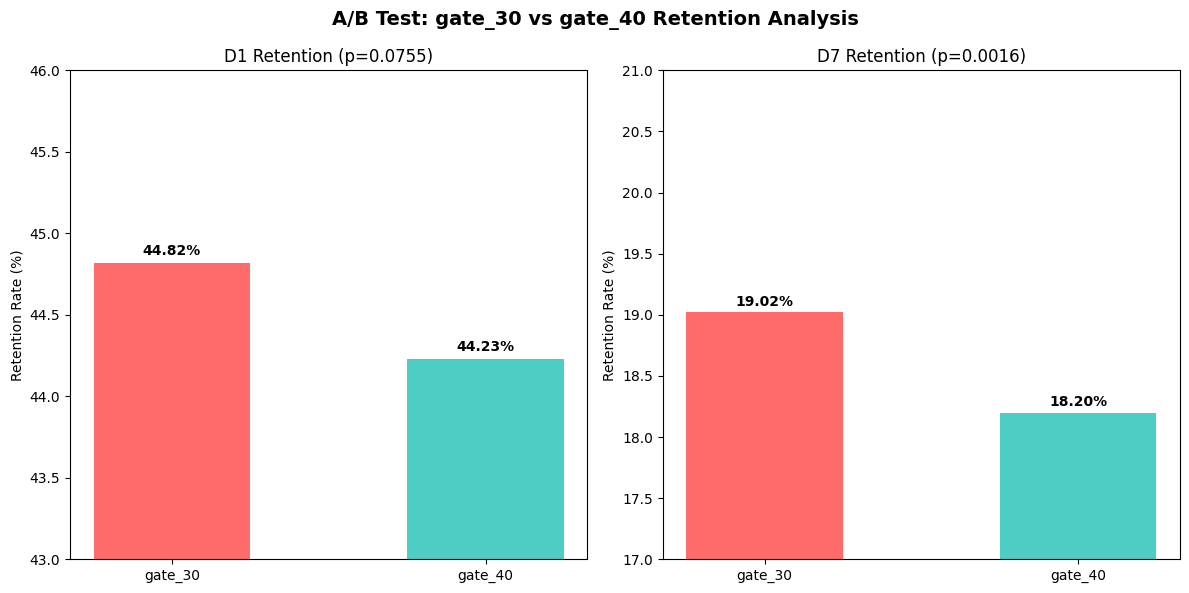

Chart saved ✅


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('A/B Test: gate_30 vs gate_40 Retention Analysis', fontsize=14, fontweight='bold')

versions = ['gate_30', 'gate_40']
d1_rates = [gate30['retention_1'].mean()*100, gate40['retention_1'].mean()*100]
d7_rates = [gate30['retention_7'].mean()*100, gate40['retention_7'].mean()*100]
colors = ['#FF6B6B', '#4ECDC4']

# D1
bars1 = axes[0].bar(versions, d1_rates, color=colors, width=0.5)
axes[0].set_title(f'D1 Retention (p={p_d1:.4f})')
axes[0].set_ylabel('Retention Rate (%)')
axes[0].set_ylim(43, 46)
for bar, val in zip(bars1, d1_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                f'{val:.2f}%', ha='center', fontweight='bold')

# D7
bars2 = axes[1].bar(versions, d7_rates, color=colors, width=0.5)
axes[1].set_title(f'D7 Retention (p={p_d7:.4f})')
axes[1].set_ylabel('Retention Rate (%)')
axes[1].set_ylim(17, 21)
for bar, val in zip(bars2, d7_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                f'{val:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/03_ab_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

## 💡 Business Insights — Retention & A/B Test

### Key Findings:
1. **D1 Retention: 44.52%** — within mobile game industry benchmark (35-45%) ✅
2. **D7 Retention: 18.61%** — below top-performing games (25-30%) → mid-game experience needs improvement
3. **gate_30 outperforms gate_40** on D7 retention (19.02% vs 18.20%)
   - p-value = 0.0016 → **statistically significant** ✅
   - D1 difference is not significant (p=0.0755) → short-term behavior is similar
   - Long-term: earlier gate placement builds stronger return habits

### Recommendations:
- ✅ Keep gate at level 30 — do not move to level 40
- 🎯 Improve D7→D30 retention by introducing daily login rewards
- 📊 Track session length and churn rate by cohort over time